### In this notebook we investigate how R^2 CV score correlates to end-point performance relative to random sampling for active learning workflow using SCARSE up to 200 peptides screened.

Load workflow data and calculate percentage improvement compared to random sampling at end-point

In [1]:
import pandas as pd
import numpy as np

df_workflow = pd.read_csv("../workflow_simulation/scripts/simulation_results/df_all.csv", sep=None, engine='python')
df_workflow.loc[df_workflow["Dataset"] == "AMP_Ecoli", "Dataset"] = "Short AMPs"
df_workflow = df_workflow[df_workflow["Metric"] == "Top 10% peptides selected (%)"]
df_workflow = df_workflow[df_workflow["Num_samples"] == 200]

# Random sampling baseline
data_size_dict = {"A0A247D711_LISMN": 1653,
                    "DN7A_SACS2": 1008,
                    "ENVZ_ECOLI": 1121,
                    "FKBP3_HUMAN": 1237,
                    "MAFG_MOUSE_sub": 1429,
                    "POLG_PESV_sub": 5130,
                    "SBI_STAAM": 1025,
                    "SDA_BACSU": 2770,
                    "SOX30_HUMAN": 1010,
                    "YNZC_BACSU_sub": 2300,
                    "Short AMPs": 1212}
data_size_endpoint = 200
y_pct_random = {
    k: data_size_endpoint / v * 100
    for k, v in data_size_dict.items()
}

# Map values to DataFrame
df_workflow["Value"] = df_workflow["Value"] / df_workflow["Dataset"].map(y_pct_random)

df_workflow_stats = (
    df_workflow
    .groupby(["Dataset", "Baseline"])["Value"]
    .agg(["mean", "std"])
    .reset_index()
)

df_workflow_stats

,Dataset,Baseline,mean,std
0,A0A247D711_LISMN,False,1.463801,0.220426
1,A0A247D711_LISMN,True,1.209877,0.245099
2,DN7A_SACS2,False,3.258535,0.216940
3,DN7A_SACS2,True,1.656713,0.514193
4,ENVZ_ECOLI,False,1.185482,0.251239
5,ENVZ_ECOLI,True,1.081319,0.188225
6,FKBP3_HUMAN,False,2.025089,0.267266
7,FKBP3_HUMAN,True,1.506347,0.382623
8,MAFG_MOUSE_sub,False,4.816629,0.250601
9,MAFG_MOUSE_sub,True,2.758070,0.236478


Load R^2 CV scores for trainig size 20,30,40,50,60,70,80,90,100

In [2]:
df_benchmark= pd.read_csv("./simulation_output/simulation_summary.csv", sep=None, engine='python')
df_benchmark = df_benchmark[['Dataset', 'Label', 'Foundation', 'Model', 'Train Size', "CV R2 Mean", "CV R2 Std"]]
dataset_map = {
    "A0A247D711_LISMN_Stadelmann_2021": "A0A247D711_LISMN",
    "DN7A_SACS2_Tsuboyama_2023_1JIC": "DN7A_SACS2",
    "ENVZ_ECOLI_Ghose_2023": "ENVZ_ECOLI",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV": "FKBP3_HUMAN",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V": "MAFG_MOUSE_sub",
    "POLG_PESV_Tsuboyama_2023_2MXD": "POLG_PESV_sub",
    "SBI_STAAM_Tsuboyama_2023_2JVG": "SBI_STAAM",
    "SDA_BACSU_Tsuboyama_2023_1PV0": "SDA_BACSU",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK": "SOX30_HUMAN",
    "EC": "Short AMPs",
    "YNZC_BACSU_Tsuboyama_2023_2JVD": "YNZC_BACSU_sub",
}
df_benchmark["Dataset_base"] = df_benchmark["Dataset"].map(dataset_map)
df_benchmark

,Dataset,Label,Foundation,Model,Train Size,CV R2 Mean,CV R2 Std,Dataset_base
0,A0A247D711_LISMN_Stadelmann_2021,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,20,-0.013436,0.111946,A0A247D711_LISMN
1,A0A247D711_LISMN_Stadelmann_2021,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,30,-0.030229,0.072636,A0A247D711_LISMN
2,A0A247D711_LISMN_Stadelmann_2021,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,40,-0.008589,0.074652,A0A247D711_LISMN
3,A0A247D711_LISMN_Stadelmann_2021,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,50,0.017025,0.083566,A0A247D711_LISMN
4,A0A247D711_LISMN_Stadelmann_2021,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,60,0.022329,0.093136,A0A247D711_LISMN
...,...,...,...,...,...,...,...,...
94,YNZC_BACSU_Tsuboyama_2023_2JVD,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,60,0.692857,0.124499,YNZC_BACSU_sub
95,YNZC_BACSU_Tsuboyama_2023_2JVD,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,70,0.727924,0.110594,YNZC_BACSU_sub
96,YNZC_BACSU_Tsuboyama_2023_2JVD,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,80,0.727016,0.086475,YNZC_BACSU_sub
97,YNZC_BACSU_Tsuboyama_2023_2JVD,score,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,90,0.755939,0.091954,YNZC_BACSU_sub


Make visualization of the correlation

In [3]:
df_merged = df_benchmark.merge(
    df_workflow_stats,
    left_on="Dataset_base",
    right_on="Dataset",
    how="inner"
)

results = []

for train_size, group in df_merged.groupby(["Train Size", "Baseline"]):
    x = group["mean"]
    y = group["CV R2 Mean"]
    
    # Pearson correlation
    corr = x.corr(y, method="pearson")
    
    results.append({
        "Train Size": train_size,
        "Correlation": corr
    })

df_results = pd.DataFrame(results)
df_results
    

,Train Size,Correlation
0,"(20, False)",0.827760
1,"(20, True)",0.790704
2,"(30, False)",0.856971
3,"(30, True)",0.790414
4,"(40, False)",0.891362
5,"(40, True)",0.796206
6,"(50, False)",0.885761
7,"(50, True)",0.788586
8,"(60, False)",0.872410
9,"(60, True)",0.753811


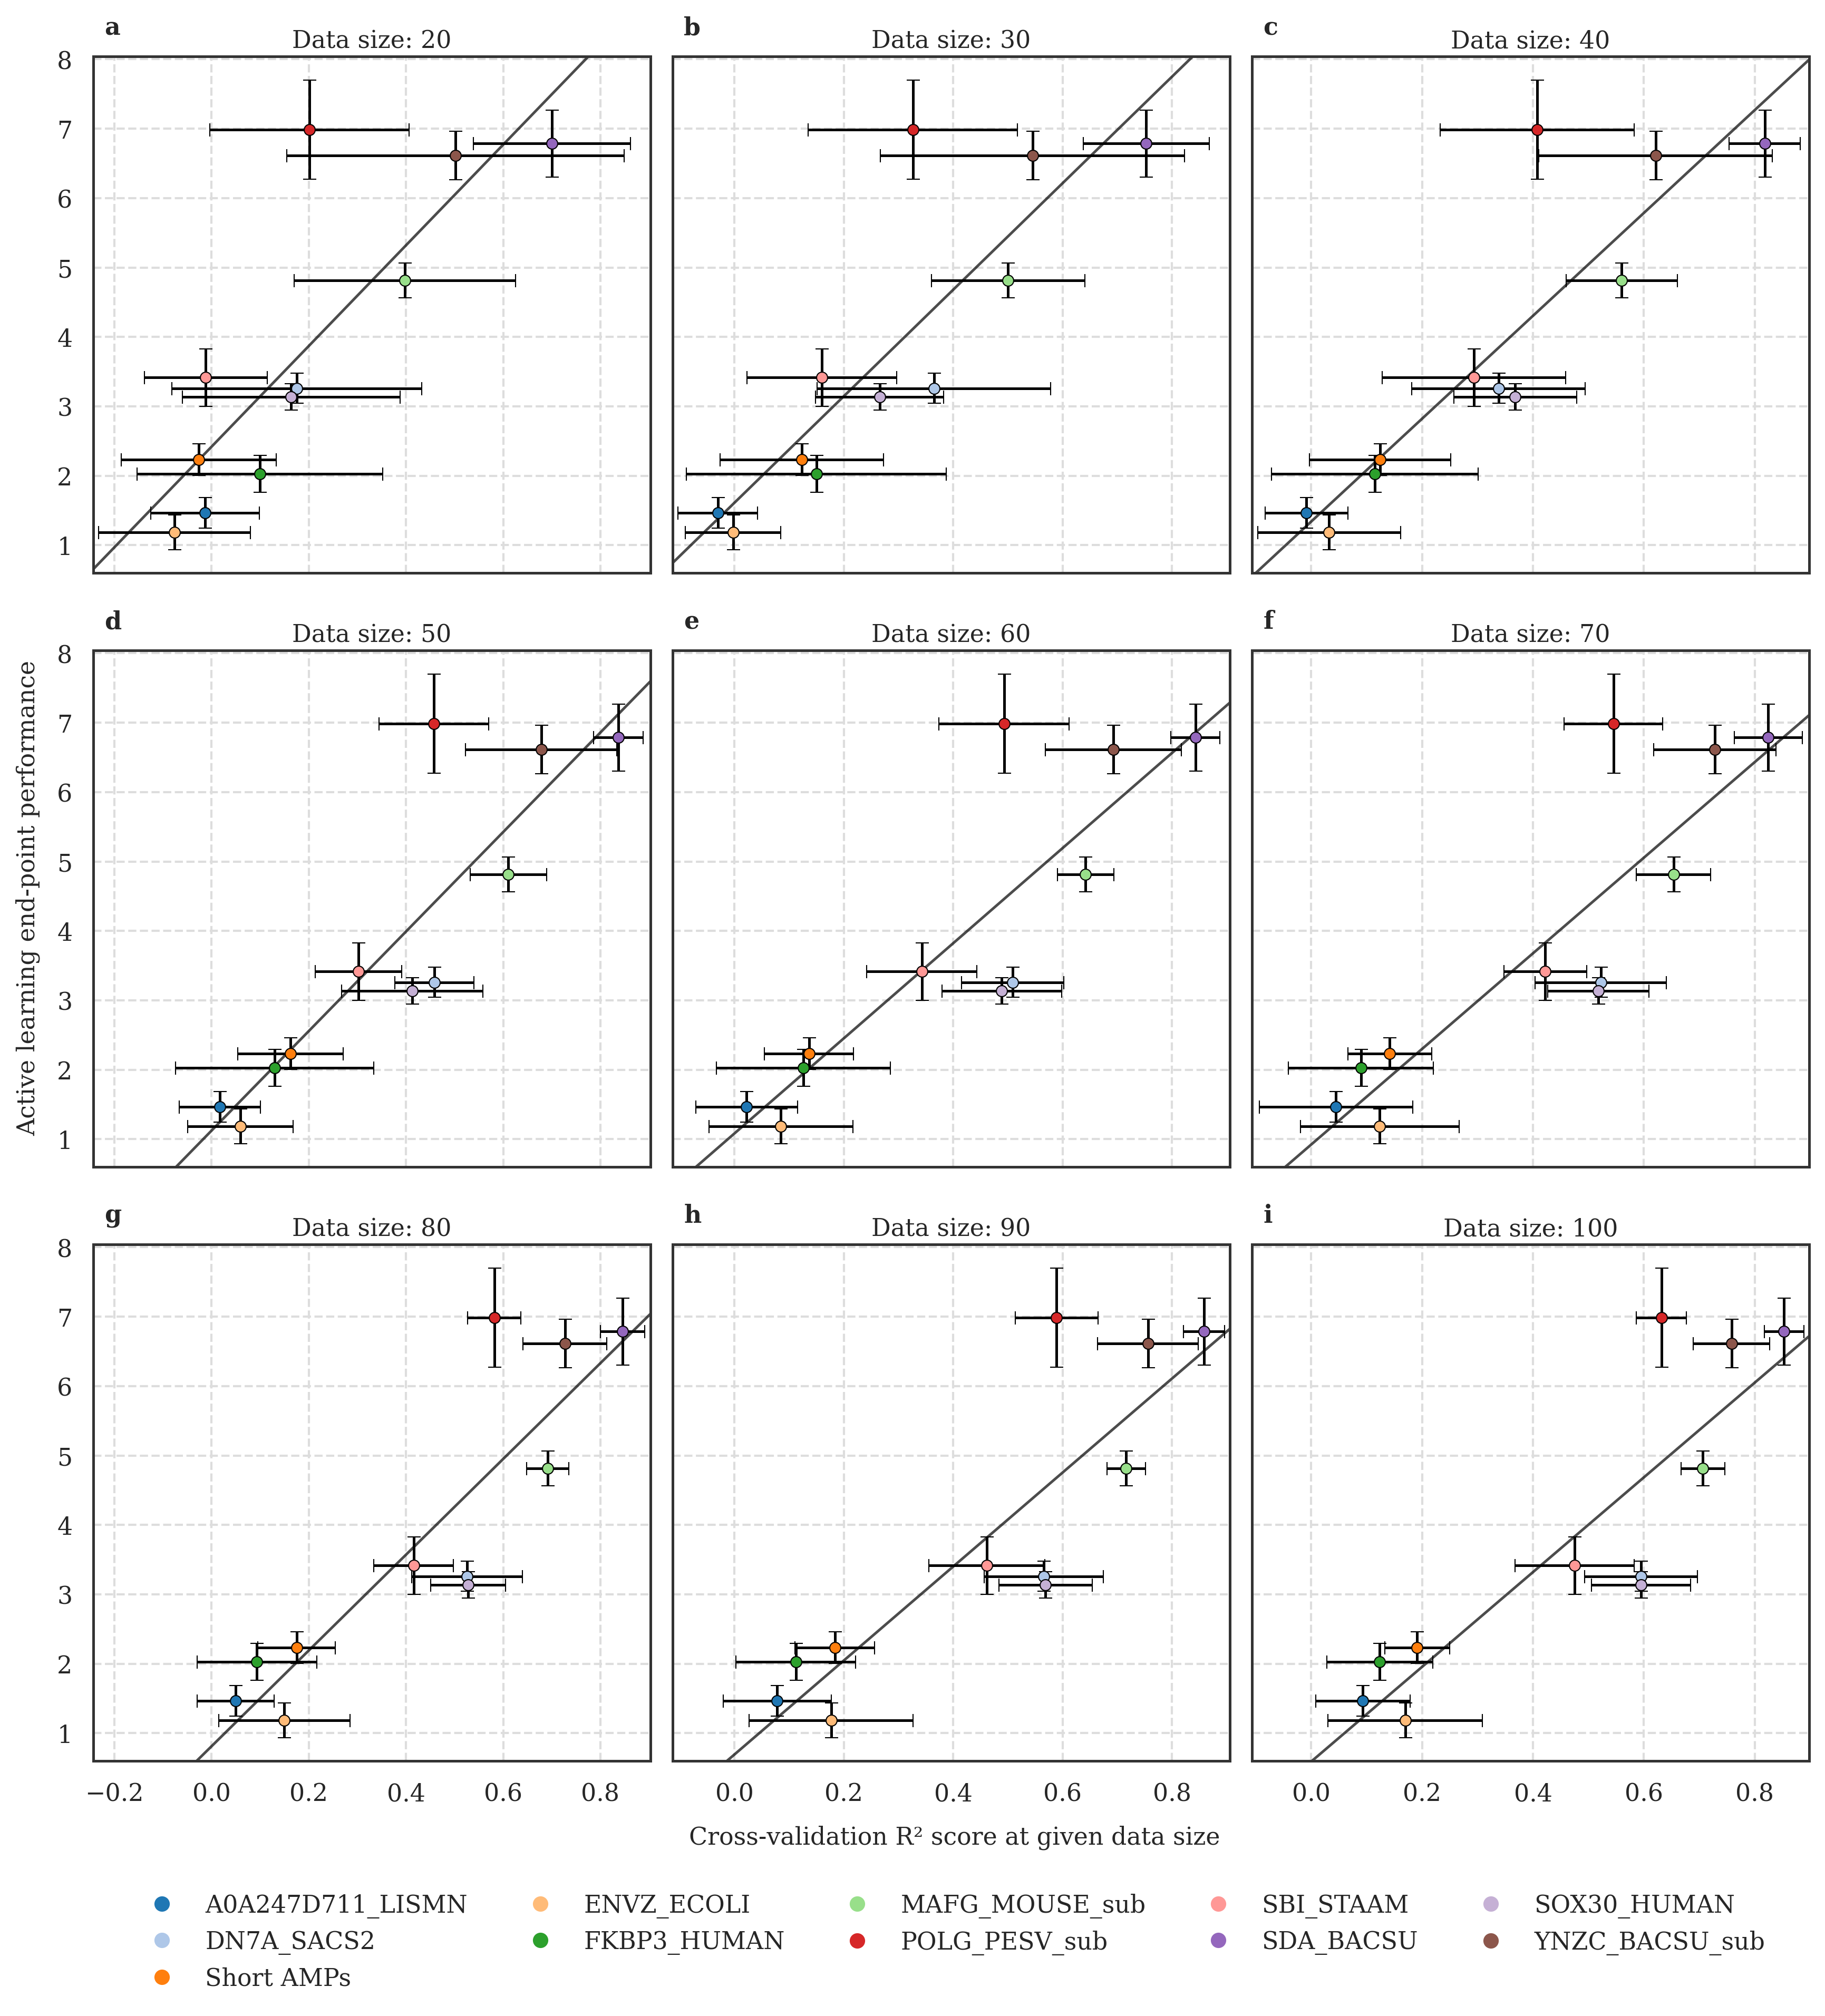

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.patheffects as pe
import string

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
    "figure.labelsize": 11, 
})

letters = list(string.ascii_lowercase)

df_merged_temp = df_merged[df_merged["Baseline"] == False]

# Color mapping 
datasets = df_merged_temp["Dataset_base"].unique()
palette = sns.color_palette("tab20", len(datasets))
color_map = dict(zip(datasets, palette))

train_sizes = sorted(df_merged_temp["Train Size"].unique())

legend_x = 0.5  
legend_y = -0.35 

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(
    nrows=3, ncols=3,
    height_ratios=[1, 1, 1],
    hspace=0.15,
    wspace=0.04
)

axes = []

for i in range(3):
    for j in range(3):
        axes.append(fig.add_subplot(gs[i, j]))

# --- Compute per-column x and y limits ---
x_lims = []
y_lims = []

for col in range(3):
    # All axes in this column
    col_axes = [axes[row*3 + col] for row in range(3) if row*3 + col < len(train_sizes)]
    # All points in these axes
    col_rows = []
    for ax in col_axes:
        train_size = train_sizes[axes.index(ax)]
        group = df_merged_temp[df_merged_temp["Train Size"] == train_size]
        col_rows.append(group)
    col_data = pd.concat(col_rows)

    # X limits for this column
    x_low  = col_data["CV R2 Mean"] - col_data["CV R2 Std"]
    x_high = col_data["CV R2 Mean"] + col_data["CV R2 Std"]
    x_margin = 0.01 * (x_high.max() - x_low.min())
    x_lims.append((x_low.min() - x_margin, x_high.max() + x_margin))

    # Y limits for this column
    y_low  = col_data["mean"] - col_data["std"]
    y_high = col_data["mean"] + col_data["std"]
    y_margin = 0.05 * (y_high.max() - y_low.min())
    y_lims.append((y_low.min() - y_margin, y_high.max() + y_margin))

for idx, train_size in enumerate(train_sizes):
    ax = axes[idx]
    group = df_merged_temp[df_merged_temp["Train Size"] == train_size]

    # Scatter + error bars 
    for _, row in group.iterrows():
        dataset = row["Dataset_base"]
        color = color_map[dataset]

        err = ax.errorbar(
            row["CV R2 Mean"],
            row["mean"],
            xerr=row["CV R2 Std"],
            yerr=row["std"],
            fmt='o',        
            markerfacecolor=color,    
            markeredgecolor='black',  
            markeredgewidth=0.5,
            markersize=5,
            ecolor='black',
            capsize=3,
            elinewidth=1.2,
            zorder=2
        )

    ax.text(
        0.02, 1.08,
        letters[idx],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        fontfamily="DejaVu Serif",
        va="top",
        ha="left"
    )

    # Regression line 
    X = group["CV R2 Mean"].values.reshape(-1, 1)
    y_vals = group["mean"].values

    if len(X) > 1:
        model = LinearRegression().fit(X, y_vals)
        x_line = np.linspace(X.min()-1, X.max()+1, 100)
        y_line = model.predict(x_line.reshape(-1, 1))
        ax.plot(
            x_line, y_line,
            color="black",
            linewidth=1.2,
            alpha=0.7
        )

    col = idx % 3
    ax.set_xlim(x_lims[col])
    ax.set_ylim(y_lims[col])

    ax.set_title(f"Data size: {train_size}", pad=4)

for k in range(len(train_sizes), len(axes)):
    fig.delaxes(axes[k])

ax_mid = None
for i, ax in enumerate(axes):
    row = i // 3
    col = i % 3

    # Only left column → y-axis
    if col != 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # Only bottom row → x-axis
    if row != 2:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    if row == 2 and col == 1:
        ax_mid = ax

fig.supxlabel("Cross-validation R² score at given data size", y=0.07, x=0.514)
fig.supylabel("Active learning end-point performance", x=0.09)


handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[d], label=d)
    for d in datasets
]

ax_mid.legend(
    handles=handles,
    loc="center",
    bbox_to_anchor=(legend_x, legend_y),
    ncol=5
)

plt.show()

### Aggregated results together with the mean substitution and short AMPs workflow performance

Worst vs random: ENVZ_ECOLI
Best vs random: YNZC_BACSU_sub


/var/folders/hl/051_xdcn7bnfs79b2g9vrw7c0000gn/T/ipykernel_6969/953973890.py:370: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


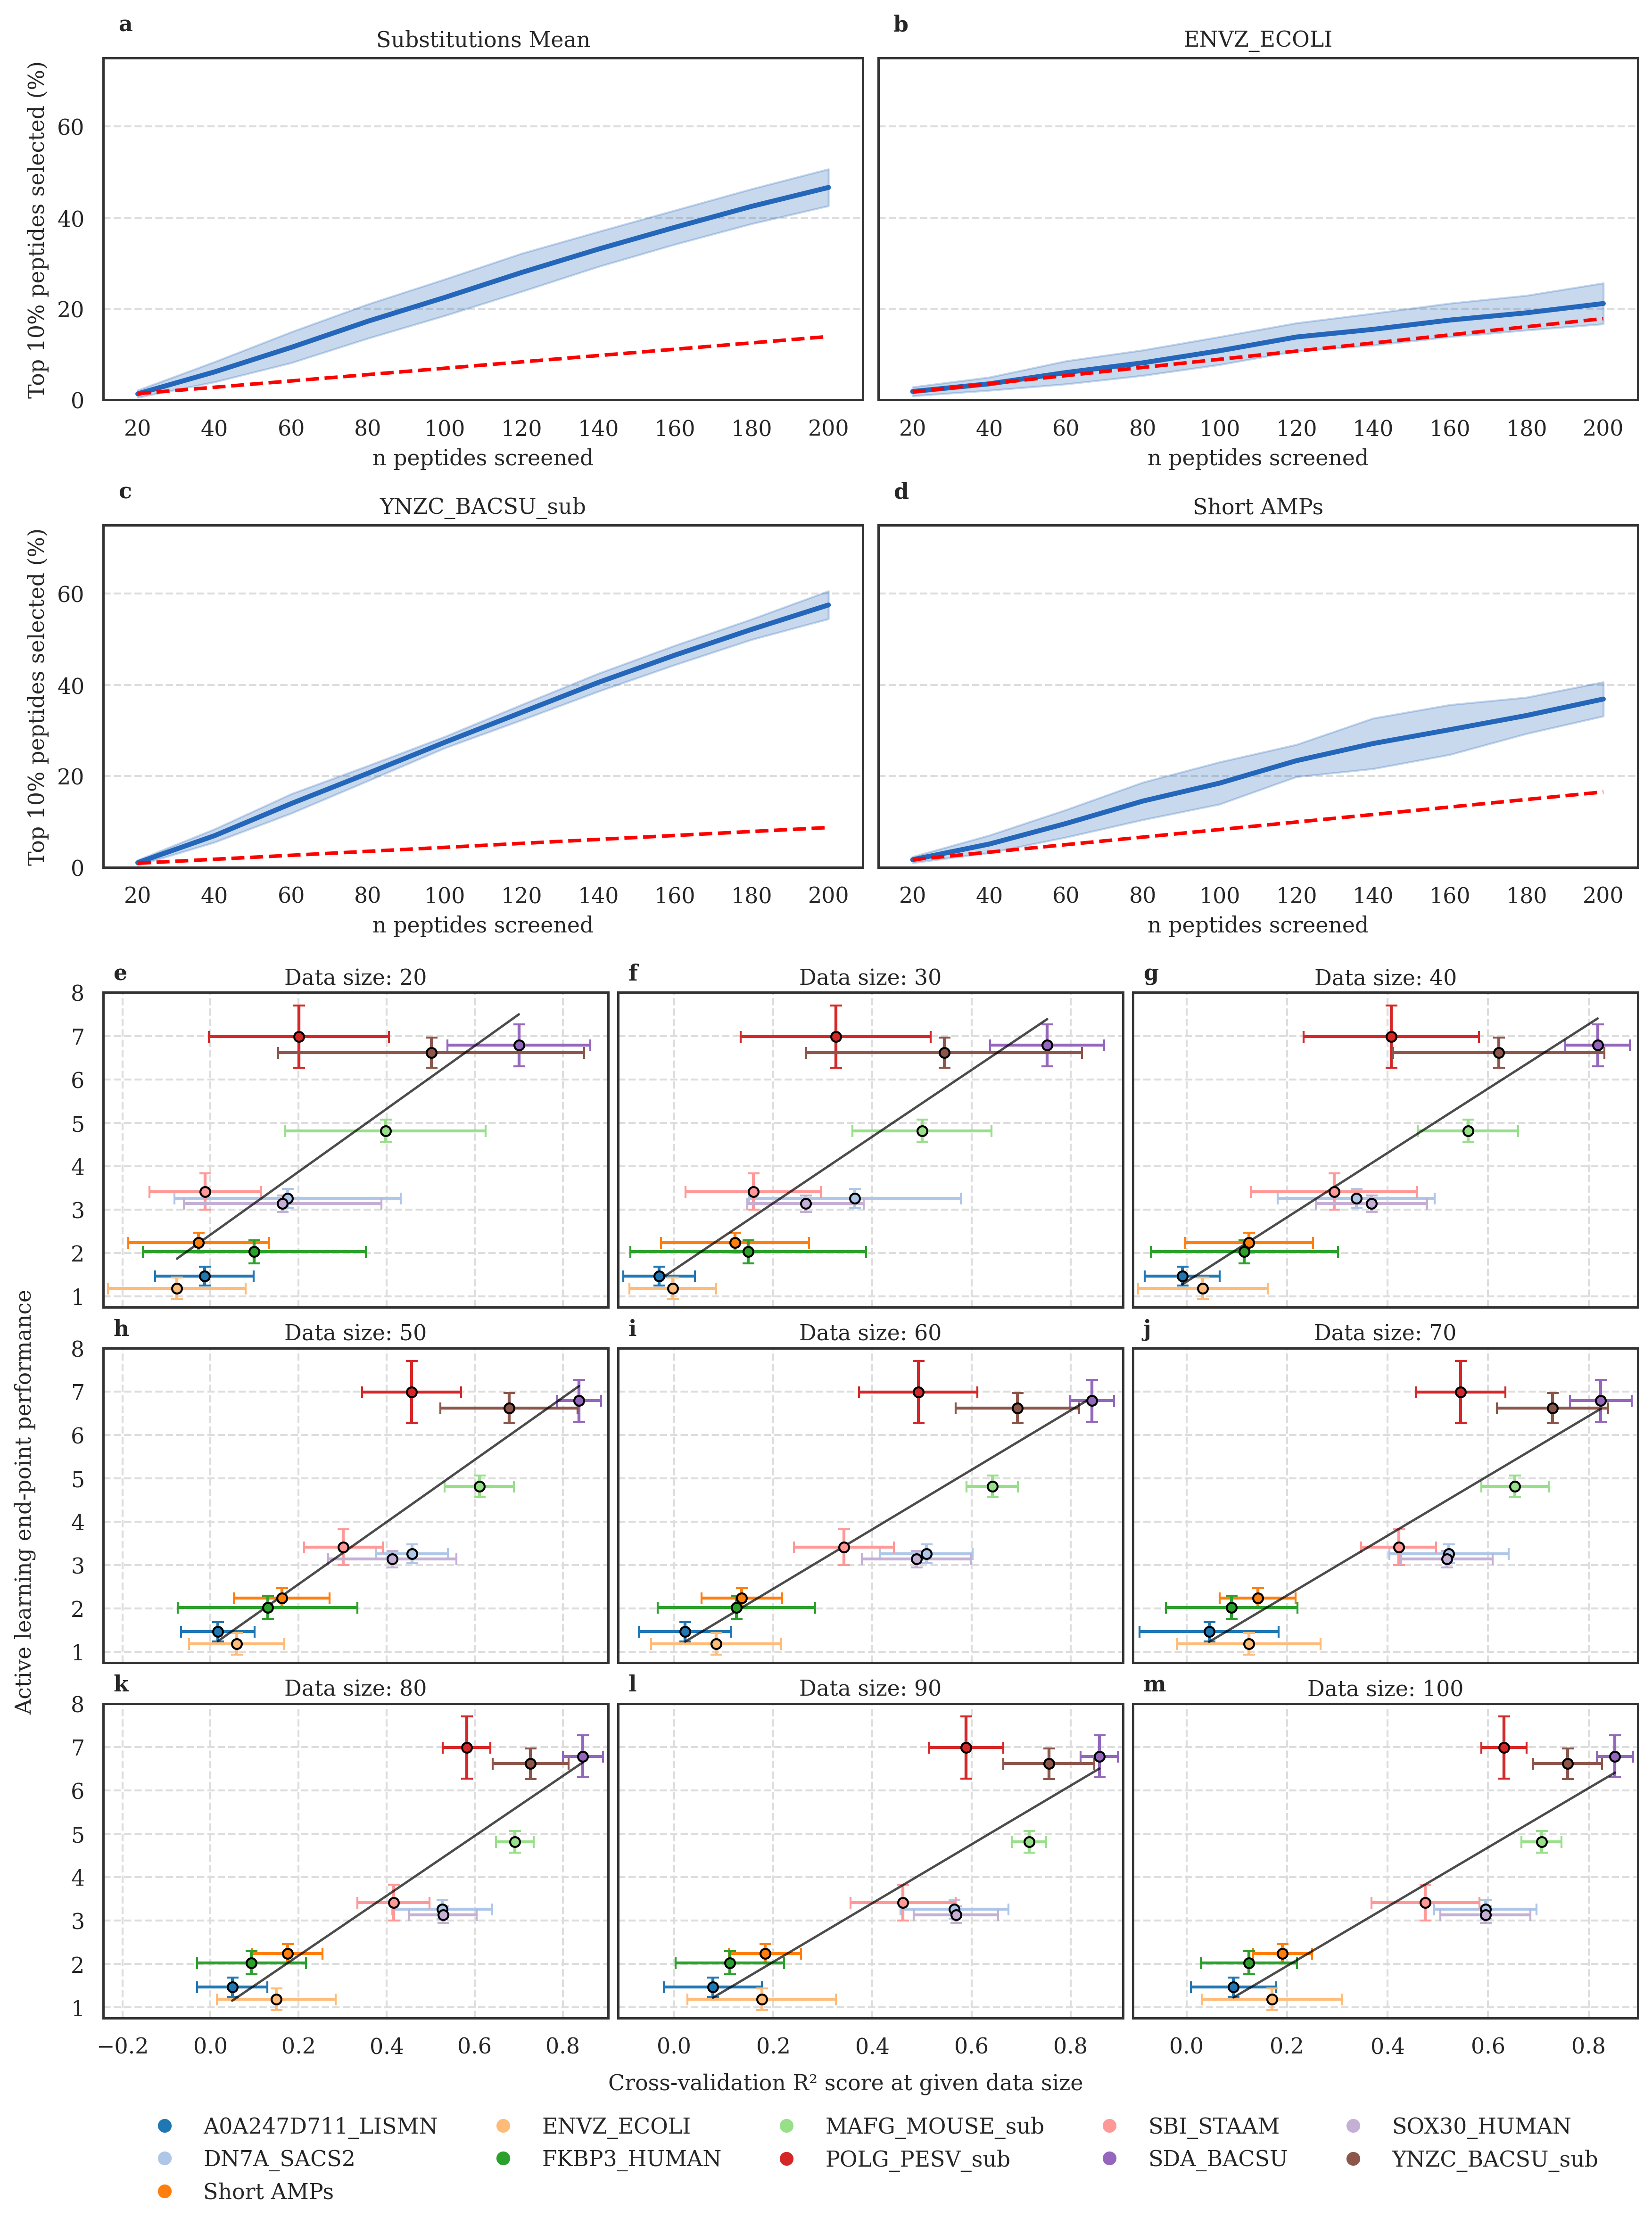

In [5]:
# =========================
# IMPORTS
# =========================
import os
import math
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../workflow_simulation/scripts/simulation_results/df_all.csv", sep=None, engine='python')
df.loc[df["Dataset"] == "AMP_Ecoli", "Dataset"] = "Short AMPs"
df = df[df["Baseline"] == False]


dataset_names = [
    "A0A247D711_LISMN", 
    "DN7A_SACS2", 
    "ENVZ_ECOLI",
    "FKBP3_HUMAN",
    "MAFG_MOUSE_sub",
    "POLG_PESV_sub",
    "SBI_STAAM",
    "SDA_BACSU",
    "SOX30_HUMAN",
    "YNZC_BACSU_sub",
    "Short AMPs",
]

# df_merged must already exist

# =========================
# STYLE
# =========================
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})


letters = list(string.ascii_lowercase)

# =========================
# RANDOM BASELINE
# =========================
data_size_dict = {
    "A0A247D711_LISMN": 1653,
    "DN7A_SACS2": 1008,
    "ENVZ_ECOLI": 1121,
    "FKBP3_HUMAN": 1237,
    "MAFG_MOUSE_sub": 1429,
    "POLG_PESV_sub": 5130,
    "SBI_STAAM": 1025,
    "SDA_BACSU": 2770,
    "SOX30_HUMAN": 1010,
    "YNZC_BACSU_sub": 2300,
    "Short AMPs": 1212
}

data_sizes = np.linspace(20, 200, 10)

y_pct_random = {
    d: [i / data_size_dict[d] * 100 for i in data_sizes]
    for d in data_size_dict
}

# =========================
# PREPARE METRIC DATA
# =========================
metric = "Top 10% peptides selected (%)"

df_metric = df[df["Metric"] == metric]

summary = (
    df_metric
    .groupby(["Dataset", "Num_samples"])["Value"]
    .agg(["mean", "std"])
    .reset_index()
)

# =========================
# BEST & WORST vs RANDOM 
# =========================

dataset_lift = {}

for dataset in summary["Dataset"].unique():
    df_d = summary[summary["Dataset"] == dataset].copy()

    if dataset not in y_pct_random:
        continue  # skip if no random baseline

    # Align values
    df_d = df_d.sort_values("Num_samples")

    y_real = df_d["mean"].values
    y_rand = np.array(y_pct_random[dataset])

    min_len = min(len(y_real), len(y_rand))
    y_real = y_real[:min_len]
    y_rand = y_rand[:min_len]

    # Compute lift (performance above random)
    lift = y_real/y_rand

    # Store mean lift
    dataset_lift[dataset] = lift.mean()

# Sort datasets by lift
dataset_lift_sorted = sorted(dataset_lift.items(), key=lambda x: x[1])

worst_dataset = dataset_lift_sorted[0][0]
best_dataset = dataset_lift_sorted[-1][0]

print("Worst vs random:", worst_dataset)
print("Best vs random:", best_dataset)

# Extract data
df_worst = summary[summary["Dataset"] == worst_dataset]
df_best = summary[summary["Dataset"] == best_dataset]

# =========================
# SPLIT DATASETS
# =========================
short_amp_dataset = "Short AMPs"
substitution_datasets = [d for d in dataset_names if d != short_amp_dataset]

df_sub = summary[summary["Dataset"].isin(substitution_datasets)]
df_short = summary[summary["Dataset"] == short_amp_dataset]

# =========================
# AGGREGATION
# =========================
agg_sub = (
    df_sub
    .groupby("Num_samples")
    .agg(
        mean=("mean", "mean"),
        std=("std", "mean")
    )
    .reset_index()
)

# Random mean curve
common_datasets = [d for d in substitution_datasets if d in data_size_dict]
random_mean = None
if len(common_datasets) > 0:
    random_curves = np.array([y_pct_random[d] for d in common_datasets])
    random_mean = random_curves.mean(axis=0)

# =========================
# FIGURE LAYOUT
# =========================
fig = plt.figure(figsize=(14, 18))

gs = GridSpec(
    nrows=3, ncols=2,
    height_ratios=[1, 1, 3],
    hspace=0.22,
    wspace=0.02
)

# Top 2x2
ax_mean  = fig.add_subplot(gs[0, 0])
ax_worst = fig.add_subplot(gs[0, 1])
ax_best  = fig.add_subplot(gs[1, 0])
ax_short = fig.add_subplot(gs[1, 1])

# Bottom
ax_bottom_spec = gs[2, :]

main_color = "#2467BA"

# =========================
# HELPER FUNCTION
# =========================
def plot_curve(ax, x, y, y_std, title, random_curve=None, show_ylabel=True):
    ax.plot(x, y, linewidth=2.5, color=main_color)
    ax.fill_between(x, y - y_std, y + y_std, alpha=0.25, color=main_color)

    if random_curve is not None:
        ax.plot(data_sizes, random_curve, color="red", linestyle="--", linewidth=1.8)

    ax.set_title(title)
    ax.set_xlabel("n peptides screened")

    if show_ylabel:
        ax.set_ylabel("Top 10% peptides selected (%)")
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.set_ylim(0, 75)
    ax.set_xticks(np.arange(20, 201, 20))
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

# =========================
# TOP PANELS
# =========================
plot_curve(
    ax_mean,
    agg_sub["Num_samples"].values,
    agg_sub["mean"].values,
    agg_sub["std"].values,
    "Substitutions Mean",
    random_mean,
    True
)

plot_curve(
    ax_worst,
    df_worst["Num_samples"].values,
    df_worst["mean"].values,
    df_worst["std"].values,
    f"{worst_dataset}",
    y_pct_random.get(worst_dataset, None),
    False
)

plot_curve(
    ax_best,
    df_best["Num_samples"].values,
    df_best["mean"].values,
    df_best["std"].values,
    f"{best_dataset}",
    y_pct_random.get(best_dataset, None),
    True
)

plot_curve(
    ax_short,
    df_short["Num_samples"].values,
    df_short["mean"].values,
    df_short["std"].values,
    "Short AMPs",
    y_pct_random.get(short_amp_dataset, None),
    False
)

# Panel letters
top_axes = [ax_mean, ax_worst, ax_best, ax_short]

for i, ax in enumerate(top_axes):
    ax.text(0.02, 1.08, letters[i], transform=ax.transAxes,
            fontsize=11, fontweight="bold")

letters = letters[4:]

# =========================
# BOTTOM GRID
# =========================
gs_bottom = ax_bottom_spec.subgridspec(3, 3, hspace=0.13, wspace=0.02)

axes = [fig.add_subplot(gs_bottom[i, j]) for i in range(3) for j in range(3)]

datasets = df_merged["Dataset_base"].unique()
palette = sns.color_palette("tab20", len(datasets))
color_map = dict(zip(datasets, palette))

train_sizes = sorted(df_merged["Train Size"].unique())

x_lims, y_lims = [], []

for col in range(3):
    col_data = pd.concat([
        df_merged_temp[df_merged_temp["Train Size"] == ts]
        for idx, ts in enumerate(train_sizes) if idx % 3 == col
    ])

    x_low = col_data["CV R2 Mean"] - col_data["CV R2 Std"]
    x_high = col_data["CV R2 Mean"] + col_data["CV R2 Std"]

    y_low = col_data["mean"] - col_data["std"]
    y_high = col_data["mean"] + col_data["std"]

    x_margin = 0.01 * (x_high.max() - x_low.min())
    y_margin = 0.05 * (y_high.max() - y_low.min())

    x_lims.append((x_low.min() - x_margin, x_high.max() + x_margin))
    y_lims.append((y_low.min() - y_margin, y_high.max() + y_margin))

for idx, train_size in enumerate(train_sizes):
    ax = axes[idx]
    group = df_merged_temp[df_merged_temp["Train Size"] == train_size]

    for _, row in group.iterrows():
        ax.errorbar(
            row["CV R2 Mean"],
            row["mean"],
            xerr=row["CV R2 Std"],
            yerr=row["std"],
            fmt='o',
            markeredgecolor='black',
            markersize=5,
            capsize=3,
            color=color_map[row["Dataset_base"]]
        )

    if len(group) > 1:
        model = LinearRegression().fit(
            group["CV R2 Mean"].values.reshape(-1, 1),
            group["mean"].values
        )
        x_line = np.linspace(group["CV R2 Mean"].min(), group["CV R2 Mean"].max(), 100)
        y_line = model.predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_line, color="black", linewidth=1.2, alpha=0.7)

    col = idx % 3
    row_i = idx // 3

    ax.set_xlim(x_lims[col])
    #ax.set_ylim(y_lims[col])
    ax.set_ylim(0.75, 8)
    ax.set_yticks(np.arange(1, 9, 1))
    ax.set_title(f"Data size: {train_size}", pad=4)

    if col != 0:
        ax.set_yticklabels([])
    if row_i != 2:
        ax.set_xticklabels([])

    ax.text(0.02, 1.04, letters[idx], transform=ax.transAxes,
            fontsize=11, fontweight="bold")

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[d], label=d)
    for d in datasets
]

axes[min(len(axes)-1, 7)].legend(
    handles=handles,
    loc="center",
    bbox_to_anchor=(0.5, -0.45),
    ncol=5
)

# Global labels
fig.supxlabel("Cross-validation R² score at given data size", y=0.08)
fig.supylabel("Active learning end-point performance", x=0.08, y=0.313)

plt.tight_layout()
plt.show()

Worst vs random: ENVZ_ECOLI
Best vs random: SDA_BACSU


/var/folders/hl/051_xdcn7bnfs79b2g9vrw7c0000gn/T/ipykernel_6969/3613999415.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


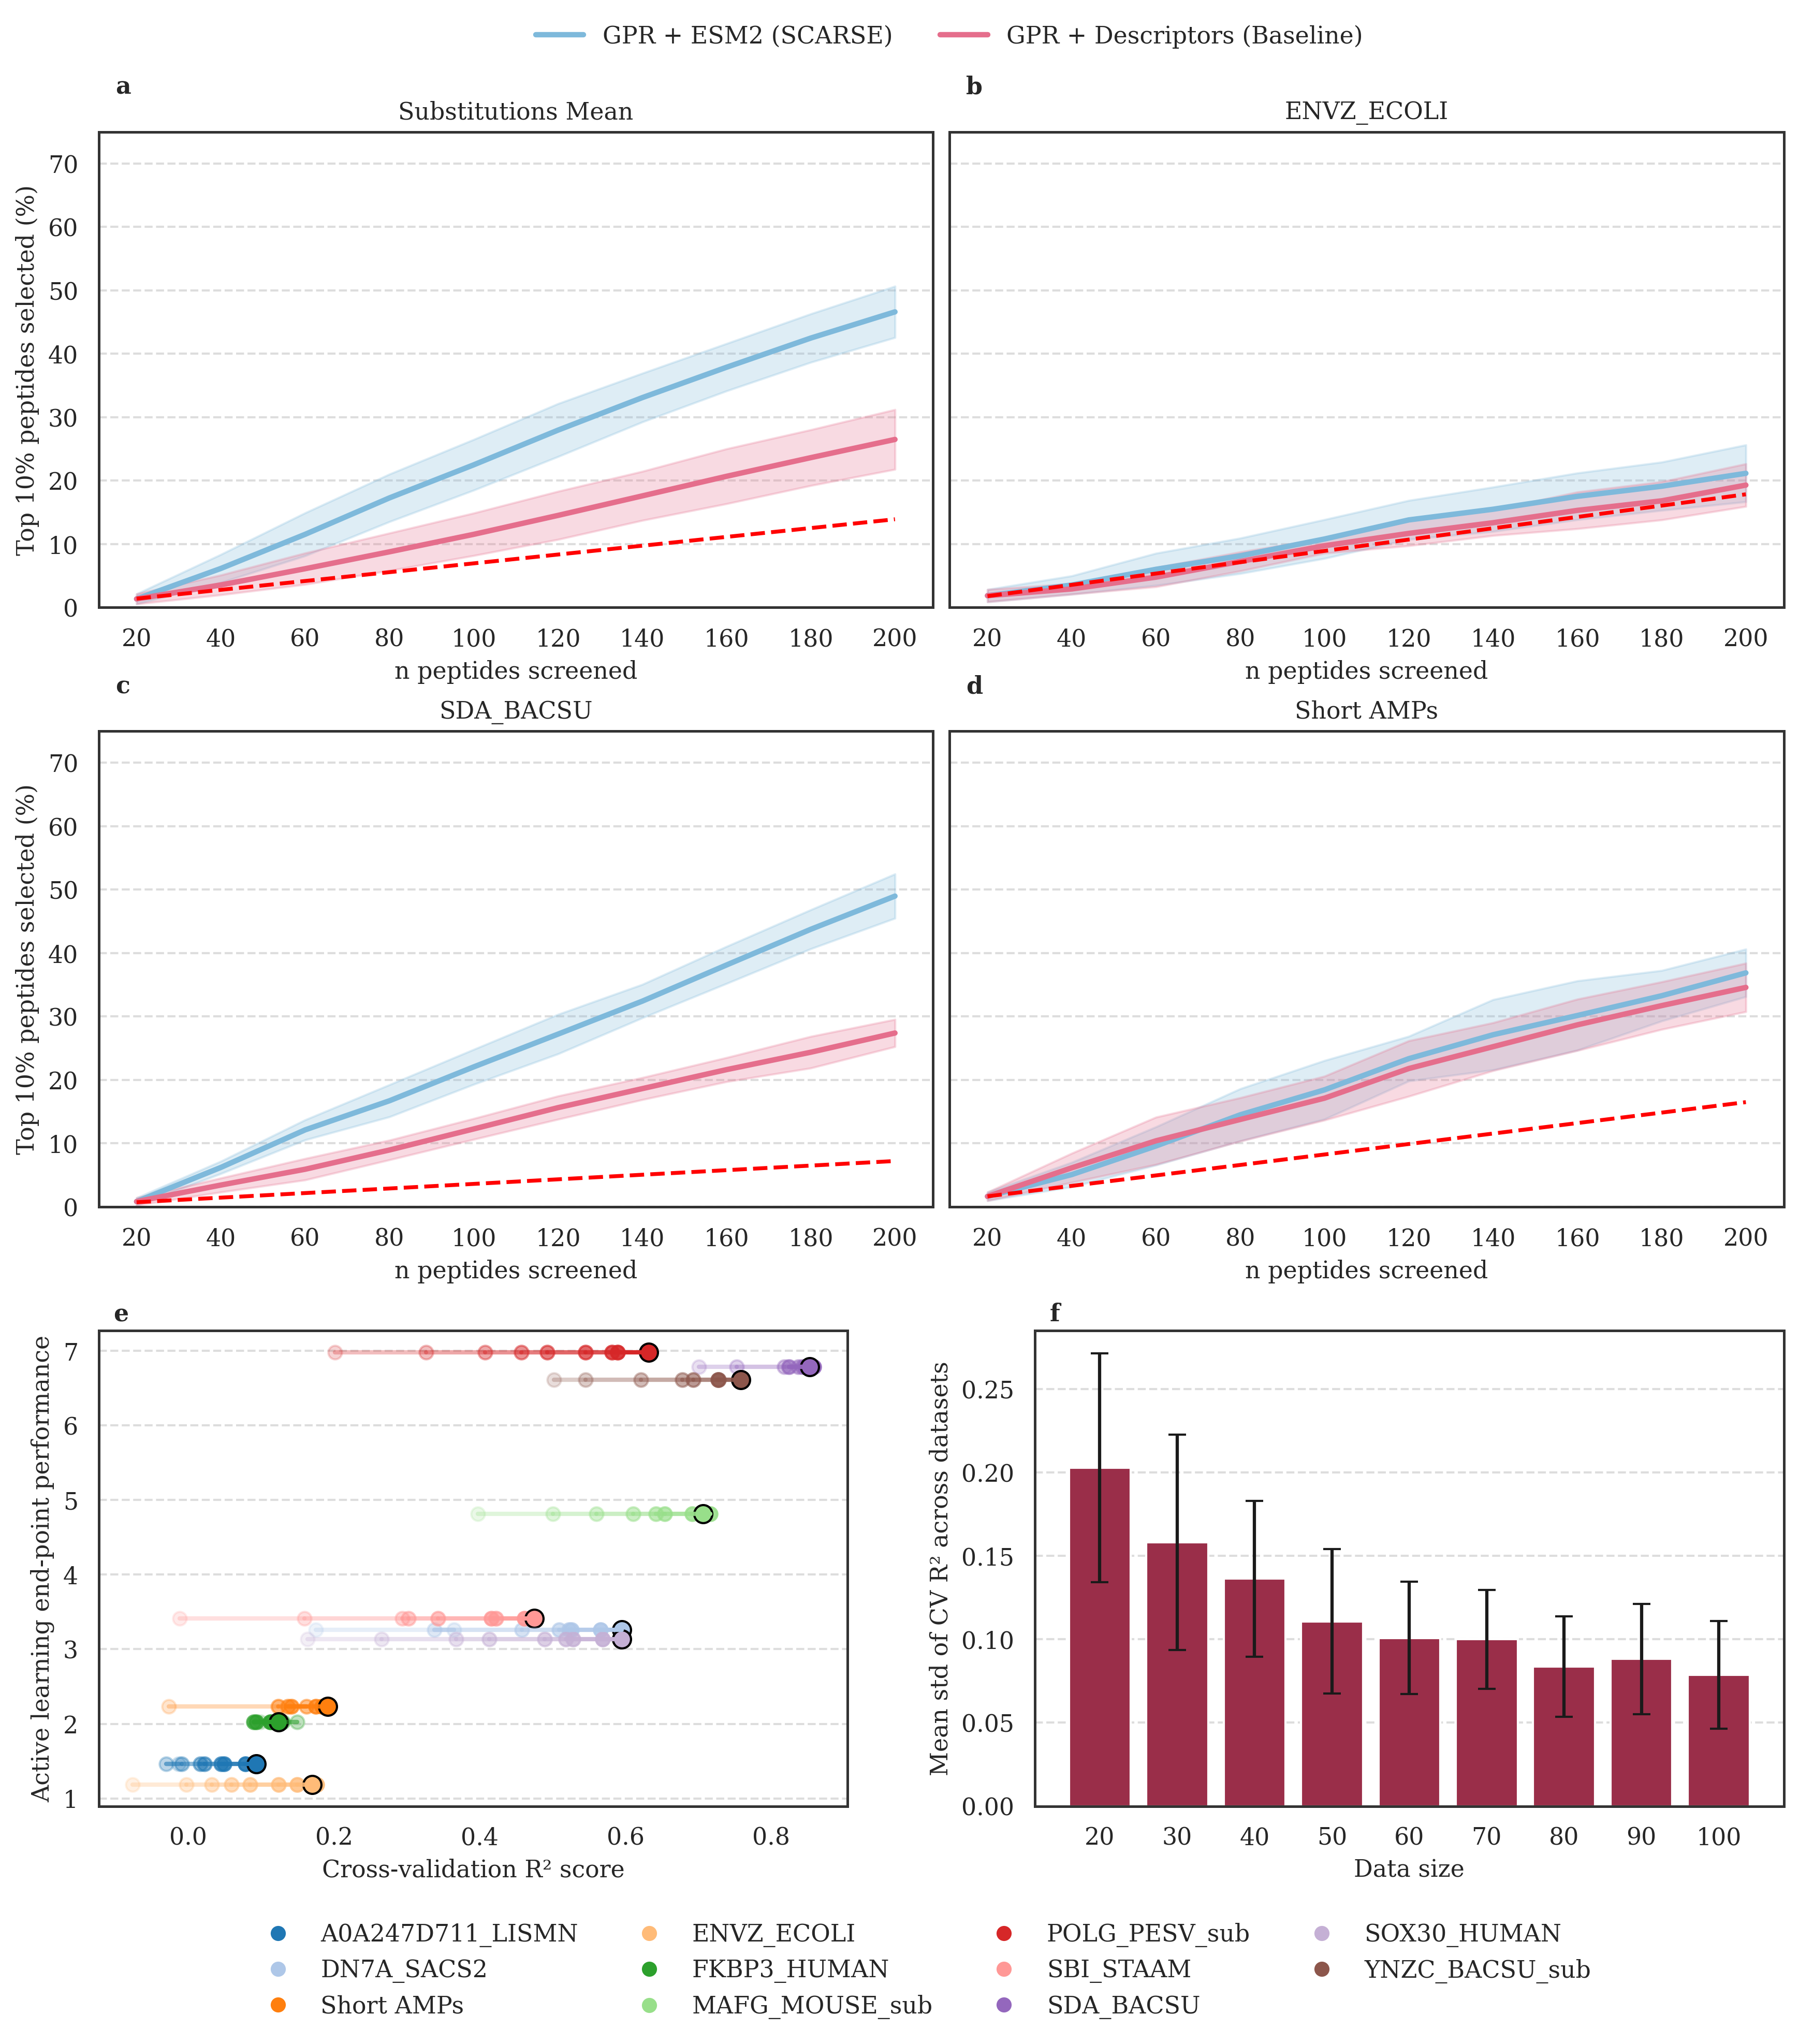

   Train Size  mean_al_std
0          20     0.325934
1          30     0.325934
2          40     0.325934
3          50     0.325934
4          60     0.325934
5          70     0.325934
6          80     0.325934
7          90     0.325934
8         100     0.325934


In [6]:
# =========================
# IMPORTS
# =========================
import os
import math
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LinearRegression

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../workflow_simulation/scripts/simulation_results/df_all.csv", sep=None, engine='python')
df.loc[df["Dataset"] == "AMP_Ecoli", "Dataset"] = "Short AMPs"

dataset_names = [
    "A0A247D711_LISMN", 
    "DN7A_SACS2", 
    "ENVZ_ECOLI",
    "FKBP3_HUMAN",
    "MAFG_MOUSE_sub",
    "POLG_PESV_sub",
    "SBI_STAAM",
    "SDA_BACSU",
    "SOX30_HUMAN",
    "YNZC_BACSU_sub",
    "Short AMPs",
]

# df_merged must already exist

# =========================
# STYLE
# =========================
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})


letters = list(string.ascii_lowercase)

# =========================
# RANDOM BASELINE
# =========================
data_size_dict = {
    "A0A247D711_LISMN": 1653,
    "DN7A_SACS2": 1008,
    "ENVZ_ECOLI": 1121,
    "FKBP3_HUMAN": 1237,
    "MAFG_MOUSE_sub": 1429,
    "POLG_PESV_sub": 5130,
    "SBI_STAAM": 1025,
    "SDA_BACSU": 2770,
    "SOX30_HUMAN": 1010,
    "YNZC_BACSU_sub": 2300,
    "Short AMPs": 1212
}

data_sizes = np.linspace(20, 200, 10)

y_pct_random = {
    d: [i / data_size_dict[d] * 100 for i in data_sizes]
    for d in data_size_dict
}

# =========================
# PREPARE METRIC DATA
# =========================
metric = "Top 10% peptides selected (%)"

df_metric = df[df["Metric"] == metric]

summary = (
    df_metric
    .groupby(["Dataset", "Num_samples", "Baseline"])["Value"]
    .agg(["mean", "std"])
    .reset_index()
)

# =========================
# BEST & WORST vs RANDOM 
# =========================

dataset_lift = {}

for dataset in summary["Dataset"].unique():
    df_d = summary[summary["Dataset"] == dataset].copy()

    if dataset not in y_pct_random:
        continue  # skip if no random baseline

    # Align values
    df_d = df_d.sort_values("Num_samples")

    y_real = df_d["mean"].values
    y_rand = np.array(y_pct_random[dataset])

    min_len = min(len(y_real), len(y_rand))
    y_real = y_real[:min_len]
    y_rand = y_rand[:min_len]

    # Compute lift (performance above random)
    lift = y_real/y_rand

    # Store mean lift
    dataset_lift[dataset] = lift.mean()

# Sort datasets by lift
dataset_lift_sorted = sorted(dataset_lift.items(), key=lambda x: x[1])

worst_dataset = dataset_lift_sorted[0][0]
best_dataset = dataset_lift_sorted[-1][0]

print("Worst vs random:", worst_dataset)
print("Best vs random:", best_dataset)

# Extract data
df_worst = summary[summary["Dataset"] == worst_dataset]
df_best = summary[summary["Dataset"] == best_dataset]

# =========================
# SPLIT DATASETS
# =========================
short_amp_dataset = "Short AMPs"
substitution_datasets = [d for d in dataset_names if d != short_amp_dataset]

df_sub = summary[summary["Dataset"].isin(substitution_datasets)]
df_short = summary[summary["Dataset"] == short_amp_dataset]

# =========================
# AGGREGATION
# =========================
agg_sub = (
    df_sub
    .groupby(["Num_samples", "Baseline"])
    .agg(
        mean=("mean", "mean"),
        std=("std", "mean")
    )
    .reset_index()
)

# Random mean curve
common_datasets = [d for d in substitution_datasets if d in data_size_dict]
random_mean = None
if len(common_datasets) > 0:
    random_curves = np.array([y_pct_random[d] for d in common_datasets])
    random_mean = random_curves.mean(axis=0)

# =========================
# FIGURE LAYOUT
# =========================
fig = plt.figure(figsize=(14, 14))

gs = GridSpec(
    nrows=3, ncols=2,
    height_ratios=[1, 1, 1],
    hspace=0.26,
    wspace=0.02
)

# Top 2x2
ax_mean  = fig.add_subplot(gs[0, 0])
ax_worst = fig.add_subplot(gs[0, 1])
ax_best  = fig.add_subplot(gs[1, 0])
ax_short = fig.add_subplot(gs[1, 1])

# Bottom
ax_bottom_spec = gs[2, :]

main_color = "#2467BA"
baseline_style = {
    False: ("GPR + ESM2 (SCARSE)", "#7eb9db"),
    True:  ("GPR + Descriptors (Baseline)", "#e56e8c"),
}

# =========================
# HELPER FUNCTION
# =========================
def plot_dataset(ax, df, dataset, title, random_curve=None, show_ylabel=True):

    df_d = df[df["Dataset"] == dataset]

    for baseline, (label, color) in baseline_style.items():

        df_b = df_d[df_d["Baseline"] == baseline]
        if df_b.empty:
            continue

        x = df_b["Num_samples"].values
        y = df_b["mean"].values
        y_std = df_b["std"].values

        ax.plot(x, y, linewidth=2.5, color=color, label=label)
        ax.fill_between(x, y - y_std, y + y_std, alpha=0.25, color=color)

    # random baseline
    if random_curve is not None:

        # if scalar → expand to flat line
        if np.isscalar(random_curve):
            random_curve = np.full_like(data_sizes, random_curve)

        ax.plot(
            data_sizes,
            random_curve,
            color="red",
            linestyle="--",
            linewidth=1.8,
            label="Random"
        )

    ax.set_title(title)
    ax.set_xlabel("n peptides screened")

    if show_ylabel:
        ax.set_ylabel("Top 10% peptides selected (%)")
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.set_ylim(0, 75)
    ax.set_xticks(np.arange(20, 201, 20))
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

def plot_curve(ax, df, random_curve=None, show_ylabel=True):

    for baseline, (label, color) in baseline_style.items():

        df_b = df[df["Baseline"] == baseline]

        x = df_b["Num_samples"].values
        y = df_b["mean"].values
        y_std = df_b["std"].values

        ax.plot(x, y, linewidth=2.5, color=color, label=label)
        ax.fill_between(x, y - y_std, y + y_std, alpha=0.25, color=color)

    if random_curve is not None:
        if np.isscalar(random_curve):
            random_curve = np.full_like(data_sizes, random_curve)

        ax.plot(
            data_sizes,
            random_curve,
            color="red",
            linestyle="--",
            linewidth=1.8,
            label="Random"
        )

    ax.set_xlabel("n peptides screened")

    if show_ylabel:
        ax.set_ylabel("Top 10% peptides selected (%)")
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.set_ylim(0, 75)
    ax.set_xticks(np.arange(20, 201, 20))
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

# =========================
# TOP PANELS
# =========================
plot_curve(
    ax_mean,
    agg_sub,
    random_mean,
    True
)
ax_mean.set_title("Substitutions Mean")

plot_dataset(
    ax_worst,
    summary,
    worst_dataset,
    worst_dataset,
    y_pct_random.get(worst_dataset, None),
    False
)

plot_dataset(
    ax_best,
    summary,
    best_dataset,
    best_dataset,
    y_pct_random.get(best_dataset, None),
    True
)

plot_dataset(
    ax_short,
    summary,
    short_amp_dataset,
    "Short AMPs",
    y_pct_random.get(short_amp_dataset, None),
    False
)

handles = [
    plt.Line2D([0], [0], color="#7eb9db", lw=2.5, label="GPR + ESM2 (SCARSE)"),
    plt.Line2D([0], [0], color="#e56e8c", lw=2.5, label="GPR + Descriptors (Baseline)")
]

ax_mean.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(1.02, 1.27)
)

# Panel letters
top_axes = [ax_mean, ax_worst, ax_best, ax_short]

for i, ax in enumerate(top_axes):
    ax.text(0.02, 1.08, letters[i], transform=ax.transAxes,
            fontsize=11, fontweight="bold")

letters = letters[4:]

# =========================
# BOTTOM: TRAJECTORY + BARPLOT
# =========================

gs_bottom = ax_bottom_spec.subgridspec(1, 2, wspace=0.25)

ax_traj = fig.add_subplot(gs_bottom[0, 0])
ax_bar  = fig.add_subplot(gs_bottom[0, 1])

# =========================
# SETTINGS
# =========================
datasets = df_merged_temp["Dataset_base"].unique()
palette = sns.color_palette("tab20", len(datasets))
color_map = dict(zip(datasets, palette))

train_sizes = sorted(df_merged_temp["Train Size"].unique())
alphas = np.linspace(0.2, 1.0, len(train_sizes))

# =========================
# LEFT PANEL: TRAJECTORIES 
# =========================

for d in datasets:
    df_d = df_merged_temp[df_merged_temp["Dataset_base"] == d].sort_values("Train Size")

    # ensure full trajectory exists
    if not set(train_sizes).issubset(set(df_d["Train Size"])):
        continue

    xs = df_d["CV R2 Mean"].values
    ys = df_d["mean"].values

    # points
    n = len(xs)
    alphas_local = np.linspace(0.2, 1.0, n)

    for i in range(n):
        ax_traj.scatter(
            xs[i],
            ys[i],
            color=color_map[d],
            alpha=alphas_local[i],
            s=40 if i < n-1 else 70,
            edgecolor="black" if i == n-1 else None
        )

    # gradient line
    n = len(xs)
    alphas_local = np.linspace(0.2, 1.0, n)

    for i in range(n - 1):
        ax_traj.plot(
            xs[i:i+2],
            ys[i:i+2],
            color=color_map[d],
            alpha=alphas_local[i+1],
            linewidth=2
        )

# labels
ax_traj.set_xlabel("Cross-validation R² score")
ax_traj.set_ylabel("Active learning end-point performance")
#ax_traj.set_title("Performance trajectory (increasing data size)")

ax_traj.grid(True, axis="y")
ax_traj.grid(False, axis="x")

# =========================
# RIGHT PANEL: MEAN STD OF CV R²
# =========================

bar_df = (
    df_merged_temp
    .groupby("Train Size")
    .agg(
        mean_std_r2=("CV R2 Std", "mean"),
        std_std_r2=("CV R2 Std", "std")  
    )
    .reset_index()
    .sort_values("Train Size")
)

# Barplot 
ax_bar.bar(
    bar_df["Train Size"].astype(str),
    bar_df["mean_std_r2"],
    yerr=bar_df["std_std_r2"],   
    capsize=4,                  
    color="#9A2E49"
)

ax_bar.set_xlabel("Data size")
ax_bar.set_ylabel("Mean std of CV R² across datasets")
#ax_bar.set_title("Model uncertainty across datasets")

ax_bar.grid(True, axis="y")
ax_bar.grid(False, axis="x")

# =========================
# PANEL LETTERS
# =========================

ax_traj.text(0.02, 1.02, letters[0], transform=ax_traj.transAxes,
             fontsize=11, fontweight="bold")
ax_bar.text(0.02, 1.02, letters[1], transform=ax_bar.transAxes,
            fontsize=11, fontweight="bold")

letters = letters[2:]

# =========================
# LEGEND
# =========================

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               color=color_map[d], label=d)
    for d in datasets
]

ax_traj.legend(
    handles=handles,
    bbox_to_anchor=(1.1, -0.2),
    loc="upper center",
    ncol=4
)

plt.tight_layout()
plt.show()

al_std_summary = (
    df_merged_temp
    .groupby("Train Size")
    .agg(
        mean_al_std=("std", "mean")  
    )
    .reset_index()
    .sort_values("Train Size")
)

print(al_std_summary)